In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, precision_score,
                             recall_score, average_precision_score,
                             PrecisionRecallDisplay)

In [2]:
df = pd.read_csv('war_economic_impact_dataset.csv')
# Cheking Imbalanced Classes
imbalance_class_count = df['War_Profiteering_Documented'].value_counts()
imbalance_class_count


War_Profiteering_Documented
Yes    69974
No     30026
Name: count, dtype: int64

In [3]:
# Checking empty_values
empty_value = df.isnull().sum()
empty_value

Conflict_Name                              0
Conflict_Type                              0
Region                                     0
Start_Year                                 0
End_Year                                   0
Status                                     0
Primary_Country                            0
Pre_War_Unemployment_%                     0
During_War_Unemployment_%                  0
Unemployment_Spike_Percentage_Points       0
Most_Affected_Sector                       0
Youth_Unemployment_Change_%                0
Pre_War_Poverty_Rate_%                     0
During_War_Poverty_Rate_%                  0
Extreme_Poverty_Rate_%                     0
Food_Insecurity_Rate_%                     0
Households_Fallen_Into_Poverty_Estimate    0
GDP_Change_%                               0
Inflation_Rate_%                           0
Currency_Devaluation_%                     0
Cost_of_War_USD                            0
Estimated_Reconstruction_Cost_USD          0
Informal_E

In [4]:
# Checking Duplicates
df.duplicated().sum()

np.int64(0)

In [5]:
# Label Encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [6]:
# droping useless columns to avoid corelation
cols_to_drop = ['Unemployment_Spike_Percentage_Points', 'Primary_Black_Market_Goods',
                'Conflict_Name', 'Primary_Country']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])


remaining = df.select_dtypes(include='object').columns.tolist()
print('Shape:', df.shape)


Shape: (100000, 24)


In [7]:
#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled


array([[ 1.68181167, -0.93519646, -2.01626776, ..., -0.44415005,
        -0.74000781, -1.52658015],
       [-1.53866163,  0.644594  ,  0.78775102, ..., -1.34122353,
        -0.68365058, -1.52658015],
       [-0.73354331,  0.644594  ,  0.38717691, ...,  1.34999691,
         1.10519593, -1.52658015],
       ...,
       [ 0.07157502,  0.644594  ,  0.85451338, ...,  0.45292343,
         0.08763115,  0.65505896],
       [-1.53866163,  0.644594  ,  0.78775102, ..., -1.34122353,
        -0.6907512 ,  0.65505896],
       [-0.73354331, -1.72509169,  0.6876075 , ..., -0.44415005,
        -0.7714169 , -1.52658015]])

In [13]:
#PCA Variance Analysis (Scree + Cumulative)


pca   = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
pca_full      = PCA().fit(X_scaled)
explained_var = pca_full.explained_variance_ratio_
cumulative    = np.cumsum(explained_var)
n_components = np.argmax(cumulative >= 0.95) + 1
print(f'selected components: {n_components}')

for t in [0.80, 0.90, 0.95]:
    n = np.argmax(cumulative >= t) + 1
    print(f'{int(t*100)}% variance → {n} components')



selected components: 15
80% variance → 10 components
90% variance → 13 components
95% variance → 15 components


In [14]:
# Checking Outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))).sum()
print(outliers[outliers > 0])

Start_Year                                 18242
End_Year                                   18242
During_War_Unemployment_%                   4533
Youth_Unemployment_Change_%                 6009
During_War_Poverty_Rate_%                   3421
Extreme_Poverty_Rate_%                      3113
Food_Insecurity_Rate_%                      3115
Households_Fallen_Into_Poverty_Estimate    13255
GDP_Change_%                                2093
Inflation_Rate_%                             502
Currency_Devaluation_%                      1538
Estimated_Reconstruction_Cost_USD              1
dtype: int64


In [15]:
# Splitting The data into Data set and Train Set
X = X_pca 
y = df.iloc[:,-1]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2,random_state=42)

In [19]:
# Building the model

model = XGBClassifier(
    scale_pos_weight = 69974 / 30026,
    n_estimators     = 200,
    max_depth        = 6,
    learning_rate    = 0.1,
    random_state     = 42,
    eval_metric      = 'auc'
)

# Training
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

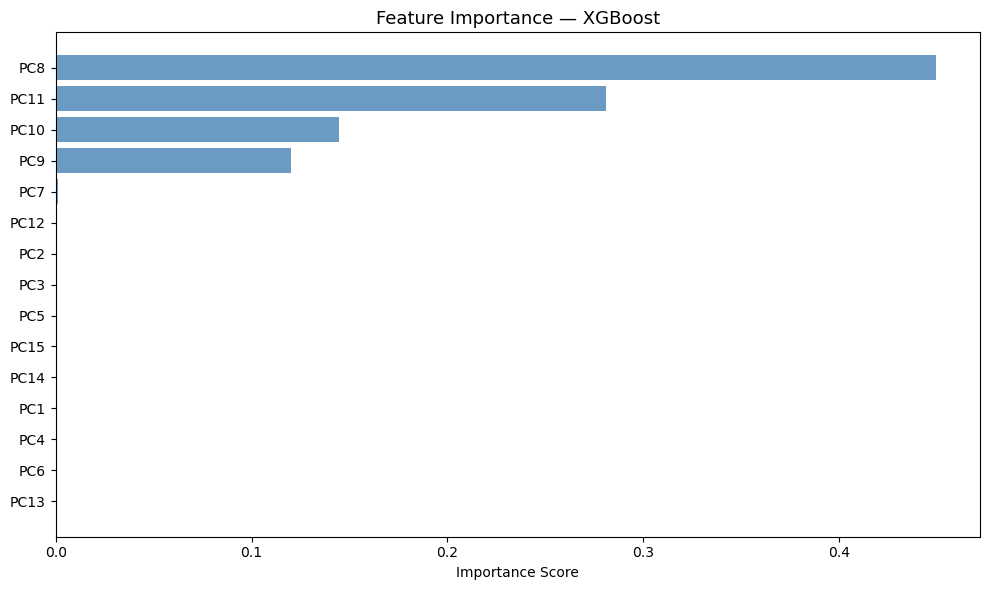

In [21]:
# ── 1. Feature Importance ──
plt.figure(figsize=(10, 6))
importance = model.feature_importances_
pca_labels = [f'PC{i+1}' for i in range(len(importance))]
sorted_idx = np.argsort(importance)

plt.barh(
    [pca_labels[i] for i in sorted_idx],
    importance[sorted_idx],
    color='steelblue', alpha=0.8
)
plt.title('Feature Importance — XGBoost', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [23]:
# Metrics
print(f'ROC-AUC Score:        {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'F1-Score (weighted):  {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'F1-Score (macro):     {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'Precision (class 1):  {precision_score(y_test, y_pred):.4f}')
print(f'Recall (class 1):     {recall_score(y_test, y_pred):.4f}')
print(f'Avg Precision Score:  {average_precision_score(y_test, y_pred_prob):.4f}')

ROC-AUC Score:        1.0000
F1-Score (weighted):  0.9994
F1-Score (macro):     0.9993
Precision (class 1):  0.9994
Recall (class 1):     0.9997
Avg Precision Score:  1.0000
